In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', None) #setting the max col width to see the whole text

In [2]:
#loading the dataset
df = pd.read_csv("SMSSpamCollection", sep="\t", header=None, names=["label","text"])

In [3]:
print("Shape:", df.shape)

Shape: (5572, 2)


In [4]:
df.head(5)

,label,text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


In [5]:
#checking if we have any missing values to clean and normalize
print("Missing labels:", df["label"].isna().sum())
print("Missing texts:", df["text"].isna().sum())
print("Empty texts :", (df["text"].astype(str).str.strip()=="").sum())

Missing labels: 0
Missing texts: 0
Empty texts : 0


In [6]:
#we are calculating the distribution of the ham and spam
counts = df["label"].value_counts()
perc = df["label"].value_counts(normalize=True) * 100

print("\nClass Counts:\n", counts)
print("\nClass Percentages:\n", perc.round(2)) #rounding up


Class Counts:
 label
ham     4825
spam     747
Name: count, dtype: int64

Class Percentages:
 label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


In [7]:
df

,label,text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"
...,...,...
5567,spam,"This is the 2nd time we have tried 2 contact u. U have won the £750 Pound prize. 2 claim is easy, call 087187272008 NOW1! Only 10p per minute. BT-national-rate."
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other suggestions?"
5570,ham,The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free


In [8]:
df["clean_text"] = df["text"].astype(str).str.lower() #adding a new column to the table clean_text and lowering the text
df.head(5)

,label,text,clean_text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...","go until jurong point, crazy.. available only in bugis n great world la e buffet... cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005. text fa to 87121 to receive entry question(std txt rate)t&c's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though","nah i don't think he goes to usf, he lives around here though"


In [9]:
df['clean_text'] = df['clean_text'].str.replace('\xa0', ' ') # we are doing the string replacement here
df.head()

,label,text,clean_text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...","go until jurong point, crazy.. available only in bugis n great world la e buffet... cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005. text fa to 87121 to receive entry question(std txt rate)t&c's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though","nah i don't think he goes to usf, he lives around here though"


In [10]:
df['clean_text'] = df['clean_text'].str.replace(r'[^\w\s]', '', regex=True) #we are eliminating the punctuation here
df.head()

,label,text,clean_text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005 text fa to 87121 to receive entry questionstd txt ratetcs apply 08452810075over18s
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives around here though",nah i dont think he goes to usf he lives around here though


In [11]:
df.clean_text.iloc[3]

'u dun say so early hor u c already then say'

In [12]:
!python -m spacy download en_core_web_sm  # I used this snippet to download the English model, so that it could be used in Spacy to do the tokenization

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------ --------------------------------- 2.1/12.8 MB 16.7 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 34.8 MB/s  0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [13]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [14]:
desc = df.clean_text.iloc[0]
desc

'go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat'

In [15]:
doc = nlp(desc)
doc

go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat

In [16]:
[token.lemma_ for token in doc if not token.is_stop] #we are doing the tokenization here

['jurong',
 'point',
 'crazy',
 'available',
 'bugis',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'get',
 'amore',
 'wat']

In [17]:
' '.join([token.lemma_ for token in doc if not token.is_stop]) #this step is basically changing the string of words into just words

'jurong point crazy available bugis n great world la e buffet cine get amore wat'

In [18]:
def token_lemma_nonstop(matter):
    doc = nlp(matter)
    output = [token.lemma_ for token in doc if not token.is_stop]
    output = ' '.join(output)
    return output

In [19]:
df['clean_text'] = df.clean_text.apply(token_lemma_nonstop)
df.head() #we are performing the tokenization on the whole clean_text column

,label,text,clean_text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",jurong point crazy available bugis n great world la e buffet cine get amore wat
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,free entry 2 wkly comp win fa cup final tkts 21st 2005 text fa 87121 receive entry questionstd txt ratetcs apply 08452810075over18s
3,ham,U dun say so early hor... U c already then say...,u dun early hor u c
4,ham,"Nah I don't think he goes to usf, he lives around here though",nah not think go usf live


In [20]:
#now lets perform the TF-IDF vectorization and stratified split
from sklearn.model_selection import train_test_split
import numpy as np

In [21]:
# Features and label
X = df["clean_text"].astype(str).to_numpy()
y = df["label"].map({"ham": 0, "spam": 1}).astype(int).to_numpy()  # ham=0, spam=1

In [22]:
# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
print("Train size:", len(X_train), " Test size:", len(X_test)) #knowing the size of the train and test data sets

Train size: 4457  Test size: 1115


In [24]:
print("Train spam %:", round(y_train.mean()*100, 2), " Test spam %:", round(y_test.mean()*100, 2)) #calculating the percentage of Test and Train spam

Train spam %: 13.42  Test spam %: 13.36


In [25]:
#Now TF-IDF vectorizer, as per the instructions from the doc
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000
)

In [26]:
#Applying the TFIDF identifiers to our train and test
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

In [27]:
print("TF-IDF Train shape:", X_train_tfidf.shape)
print("TF-IDF Test shape :", X_test_tfidf.shape)
print("Vocabulary size   :", len(vectorizer.get_feature_names_out()))

TF-IDF Train shape: (4457, 6881)
TF-IDF Test shape : (1115, 6881)
Vocabulary size   : 6881


In [28]:
#since we are working with ANN, these has to be converted to dense since Keras dense layers expect the dense input, and since the data size is small enough, we can safely convert
X_train_dense = X_train_tfidf.toarray().astype("float32")
X_test_dense  = X_test_tfidf.toarray().astype("float32")

print("Dense Train shape:", X_train_dense.shape)
print("Dense Test shape :", X_test_dense.shape)

Dense Train shape: (4457, 6881)
Dense Test shape : (1115, 6881)


In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [30]:
#we are building an ANN here with Dense layers and Dropout layers
input_dim = X_train_dense.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)), #starting with input layer
    layers.Dense(128, activation="relu"), #then dense layer
    layers.Dropout(0.3), #then dropout layer
    layers.Dense(64, activation="relu"), #then dense layer again
    layers.Dropout(0.3), #then dropout again
    layers.Dense(1, activation="sigmoid") #finally the Dense layer
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         880,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 889,217 (3.39 MB)

 Trainable params: 889,217 (3.39 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# training the ANN with 10-20 epochs
#we are setting up call backs here, 
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3, #If the error doesn't get better for 3 full training cycles, we are stopping early to prevent the model from just memorizing instead of learning generally, basically called overfitting
        restore_best_weights=True #if it stops early, roll back to the version of the model that performed best so far
    )
]

history = model.fit(
    X_train_dense, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8640 - loss: 0.3604 - val_accuracy: 0.8430 - val_loss: 0.2199
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9689 - loss: 0.0946 - val_accuracy: 0.9709 - val_loss: 0.1000
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9924 - loss: 0.0272 - val_accuracy: 0.9731 - val_loss: 0.0939
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9966 - loss: 0.0119 - val_accuracy: 0.9697 - val_loss: 0.1233
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9980 - loss: 0.0059 - val_accuracy: 0.9720 - val_loss: 0.1218
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9997 - loss: 0.0019 - val_accuracy: 0.9720 - val_loss: 0.1405


In [32]:
# Calculating the evaluation metrics, confusion matrix, curves
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# probability + class prediction
y_prob = model.predict(X_test_dense).ravel()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall   : {rec:.4f}")
print(f"Test F1-score : {f1:.4f}\n")

print(classification_report(y_test, y_pred, target_names=["ham","spam"]))


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Test Accuracy : 0.9749
Test Precision: 0.9116
Test Recall   : 0.8993
Test F1-score : 0.9054

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.91      0.90      0.91       149

    accuracy                           0.97      1115
   macro avg       0.95      0.94      0.95      1115
weighted avg       0.97      0.97      0.97      1115



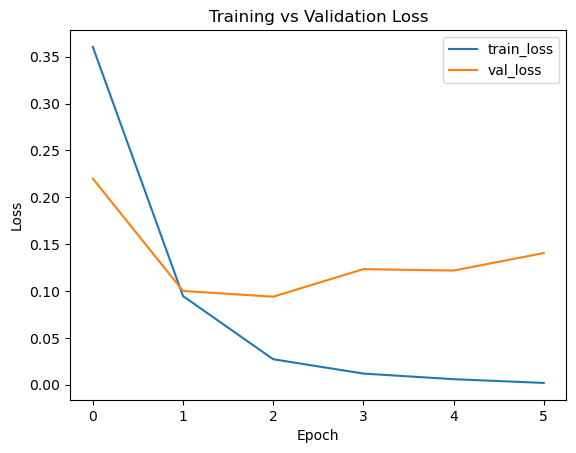

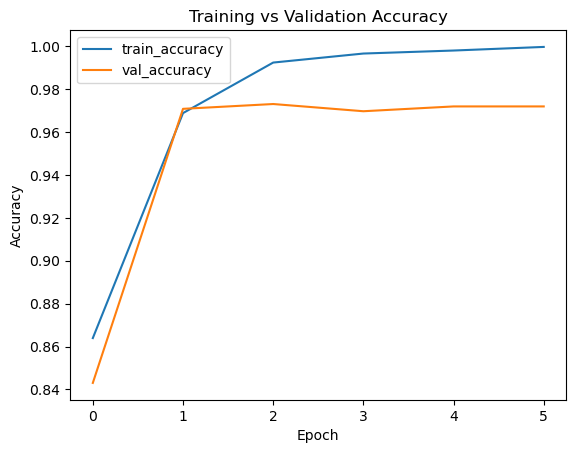

In [33]:
import matplotlib.pyplot as plt
#checking whether the model is overfitting (train improves while val worsens) and validating training stability
# Loss
plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Accuracy
plt.figure()
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Confusion Matrix:
 [[953  13]
 [ 15 134]]


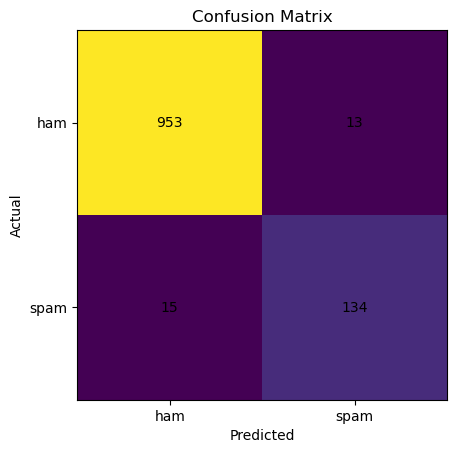

In [37]:
#showing counts of TP/TN/FP/FN
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["ham","spam"])
plt.yticks([0,1], ["ham","spam"])
for (i, j), v in __import__("numpy").ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.show()

In [38]:
#identifying 5 FPs + 5FNs, and why did they occur

import pandas as pd

analysis_df = pd.DataFrame({
    "text": X_test,          # clean_text from test split
    "y_true": y_test,
    "y_prob": y_prob,
    "y_pred": y_pred
})

# False Positives: ham (0) predicted as spam (1)
fp = analysis_df[(analysis_df["y_true"] == 0) & (analysis_df["y_pred"] == 1)].copy()
# False Negatives: spam (1) predicted as ham (0)
fn = analysis_df[(analysis_df["y_true"] == 1) & (analysis_df["y_pred"] == 0)].copy()

fp_top5 = fp.sort_values("y_prob", ascending=False).head(5)
fn_top5 = fn.sort_values("y_prob", ascending=True).head(5)

print("False Positives (ham -> spam):")
display(fp_top5[["y_prob","text"]])

print("False Negatives (spam -> ham):")
display(fn_top5[["y_prob","text"]])

False Positives (ham -> spam):


,y_prob,text
78,0.969907,u receive msg
459,0.923319,ur hdd casing cost
390,0.912735,number u live 11
380,0.907222,ku not msg reply msg
782,0.873415,cost hire hitman


False Negatives (spam -> ham):


,y_prob,text
219,0.000646,sorry miss let talk time m 07090201529
606,0.001034,email alertfrom jeri stewartsize 2kbsubject lowcost prescripiton drvgsto listen email 123
1069,0.002495,hi ya babe x u 4goten bout scammer get smartthough regular vodafone respond prem rate msgsubscription nos beware
852,0.004398,realize 40 year thousand old lady run tattoo
823,0.007771,xclusiveclubsaisai 2morow 285 soiree speciale zouk nichols parisfree rose 2 lady info 0794674629107880867867


In [39]:
#Lets train a simple logistic regression model to compare the results with our above ANN model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced")   # important due to class imbalance

baseline_model.fit(X_train_tfidf, y_train)

y_pred_lr = baseline_model.predict(X_test_tfidf)

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr  = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr   = f1_score(y_test, y_pred_lr, zero_division=0)

print("Logistic Regression Baseline")
print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")

Logistic Regression Baseline
Accuracy : 0.9740
Precision: 0.8896
Recall   : 0.9195
F1-score : 0.9043


In [40]:
#Comparing the results

results = pd.DataFrame([
    {
        "Model": "ANN (TF-IDF)",
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    },
    {
        "Model": "Logistic Regression (TF-IDF)",
        "Accuracy": acc_lr,
        "Precision": prec_lr,
        "Recall": rec_lr,
        "F1-score": f1_lr
    }
])

results

,Model,Accuracy,Precision,Recall,F1-score
0,ANN (TF-IDF),0.974888,0.911565,0.899329,0.905405
1,Logistic Regression (TF-IDF),0.973991,0.889610,0.919463,0.904290
